# Unsupervised NN

### Model Character
input:
- distribution of d_k (sum = 1)
- |H_k|

output:
- list of b_k
- list of f_dt_k
- list of beta_k

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import numpy as np
import torch


if torch.backends.mps.is_available():
    device = 'mps'
    print("Success: Using Apple Silicon GPU acceleration.")
elif torch.cuda.is_available():
    device = 'cuda'
    print("Success: Using Cuda GPU acceleration.")
else:
    device = 'cpu'
    print("Using CPU.")

Success: Using Cuda GPU acceleration.


Read Data

In [35]:
from NNSolver import Net


K = 4
B_total = 100e3
C_DT_total = 50e6
beta_max = 3
model = Net(K, B_total, C_DT_total, beta_max)

In [36]:
from DataUtil import generate_data_loader


train_loader, test_loader = generate_data_loader(int(1e5), K, 16e3, beta_max=3.5)

In [37]:
from TrainingUtil import unsupervised_loss, train
from torch.optim import Adam, lr_scheduler
from EarlyStopping import EarlyStopping


optimizer = Adam(model.parameters(), lr=0.01)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopper = EarlyStopping(patience=7, min_delta=0.1)
loss_fn = unsupervised_loss

train(model, train_loader, test_loader, optimizer, scheduler, early_stopper, loss_fn, device, n_epoch=100)

start training
epoch: 01, avg loss: 1506.8549940031983


KeyboardInterrupt: 

In [ ]:
# state_dict = torch.load('model/checkpoint.pth', map_location=device, weights_only=True)
# model.to(device)
# model.load_state_dict(state_dict)

## NN

|   sensor_num |          b |    H(dB) |             f |   beta |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|-----------:|---------:|--------------:|-------:|--------------:|-------------:|-----------:|-----------:|
|       0.0000 | 22315.6855 | -40.0000 |  8821366.0000 | 1.5000 |        3.3935 |       0.7873 |     1.4727 |     1.1336 |
|       1.0000 | 33052.9414 | -40.0000 | 23535902.0000 | 2.0000 |        6.8445 |       5.3176 |     1.1020 |     0.4249 |
|       2.0000 | 22315.6855 | -40.0000 |  8821366.0000 | 1.5000 |        3.3935 |       0.7873 |     1.4727 |     1.1336 |
|       3.0000 | 22315.6855 | -40.0000 |  8821366.0000 | 1.5000 |        3.3935 |       0.7873 |     1.4727 |     1.1336 |

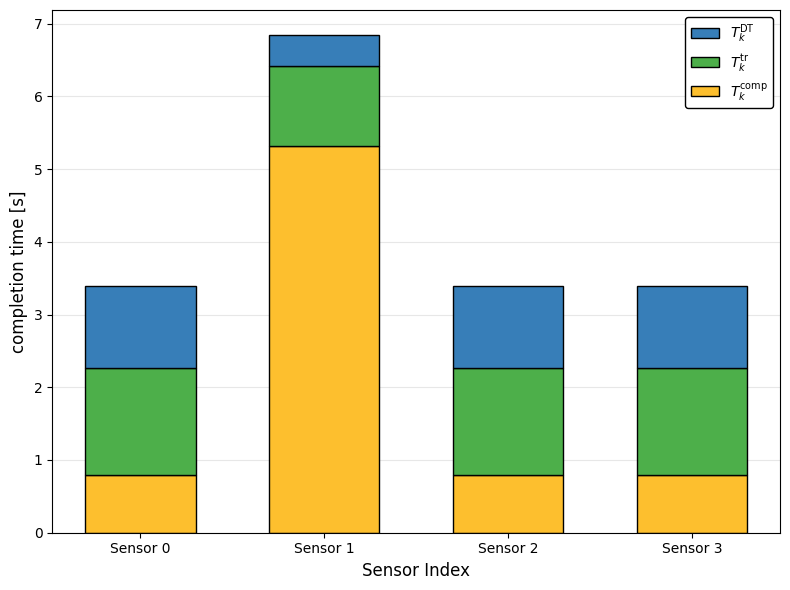

In [ ]:
import TrainingUtil as tu
import DataUtil as du
import AnalyzeUtil as au
import ProcessTime as process

length=1000

H = au.to_normal(-40)

H_k = torch.tensor([H, H, H, H])
test_d = torch.tensor([1e3, 1e3, 1e3, 1e3])
test_beta = torch.tensor([1.5, 2, 1.5, 1.5])
X_test = torch.cat((test_d, H_k, test_beta)).reshape(1, -1).to('cuda')

b, f = model(X_test)

b = b.to('cpu')
f = f.to('cpu')
au.plot_result(X_test.to('cpu'), b, f)
au.print_avg(X_test.to('cpu'), b, f)


## Traditional

step=0, loss=7.221258e+00
step=100, loss=6.754570e+00
step=200, loss=6.680806e+00
step=300, loss=6.654814e+00
step=400, loss=6.659322e+00


|   sensor_num |          b |    H(dB) |             f |   beta |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|-----------:|---------:|--------------:|-------:|--------------:|-------------:|-----------:|-----------:|
|       0.0000 |  5878.7153 | -40.0000 |  2768506.7500 | 1.5000 |        5.9006 |       0.7873 |     1.5013 |     3.6121 |
|       1.0000 | 83324.1797 | -40.0000 | 42057876.0000 | 2.0000 |        6.6542 |       5.3176 |     1.0988 |     0.2378 |
|       2.0000 |  5533.5107 | -40.0000 |  2638587.7500 | 1.5000 |        6.0809 |       0.7873 |     1.5037 |     3.7899 |
|       3.0000 |  5263.6011 | -40.0000 |  2535029.2500 | 1.5000 |        6.2378 |       0.7873 |     1.5058 |     3.9447 |

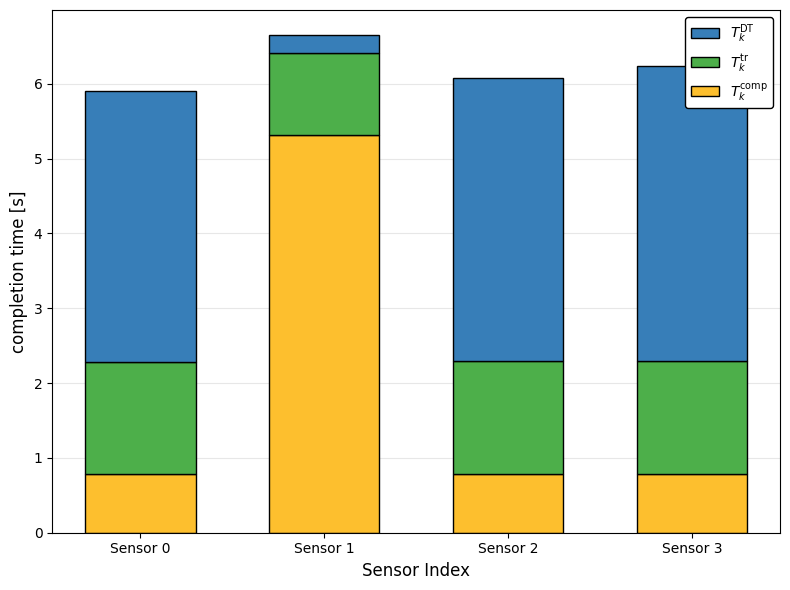

In [ ]:
from TraditionalSolver import TraditionalLeaderOptimizer

leader_solver = TraditionalLeaderOptimizer(
    K=K,
    min_share=1e-4,
    dtype=torch.float32,
    device="cuda",
)

result = leader_solver.solve(
    X_test,
    steps=500,
    lr=1e-2,
    tau=None,
    optimizer_type="adam",
    verbose=True,
)

au.plot_result(X_test.to('cpu'), result["b"].to('cpu'), result['f'].to('cpu'))
au.print_avg(X_test.to('cpu'), result["b"].to('cpu'), result['f'].to('cpu'))
